# Multitask Shapes – interactive play  
  
This notebook lets you **play the customised “Multitask Shapes” environment** that you pasted.  
At each step you’ll be asked for an action:

| index | meaning  |
|-------|----------|
| 0     | **UP**   |
| 1     | **DOWN** |
| 2     | **LEFT** |
| 3     | **RIGHT**|
| 4     | **PICK** |
| 5     | **DROP** |

The notebook will  
* execute the action,  
* print the new reward & raw observation, and  
* display the rendered frame.

> **Prerequisites**  
> * `shapes.py`, `multitask_shapes.py`, `utils.py`, the `assets/` folder and your YAML hyper‑parameter file must be provided.
> * Python ≥ 3.9 with the packages in the first code‑cell installed.


In [1]:
# ------------------------------------------------------------
# (Optional) install runtime dependencies
# ------------------------------------------------------------
# If you are missing any of these packages, remove the leading
# '#' and run the cell once.
#
# !pip install -q gymnasium numpy opencv-python-headless matplotlib pyyaml


In [2]:
# ------------------------------------------------------------
# Imports & utility helpers
# ------------------------------------------------------------
import os, yaml, numpy as np, cv2, matplotlib.pyplot as plt
from typing import Dict
from IPython.display import clear_output
import time

# Adjust the import below if your python file has a different name
from envs.shapes.multitask_shapes import ShapesAttrCombFactory
from utils import setup_artefact_paths

# Helper to display a rendered frame inline
def show_frame(img):
    plt.figure(figsize=(4,4))
    # convert BGR (OpenCV) ➜ RGB (matplotlib)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# TODO: What happens when the door is re-locked? What happens if the agent is standing on it?
def semantically_interpretable_state(obs:np.ndarray, door_idx_0:int, agent_idx_0:int, features:Dict):
    # 5 features per each object
    num_objs = int(door_idx_0/5)
    # 4 features per each door
    num_doors = int((agent_idx_0-door_idx_0)/4)

    print(f"Agent is at {obs[agent_idx_0]}, {obs[agent_idx_0+1]}.")

    for obj_id in range(num_objs):
        obj_x = obs[obj_id*5]
        obj_y = obs[obj_id*5+1]
        obj_picked_up = obs[obj_id*5+4]

        obj_clr_ftr = obs[obj_id*5+2]
        obj_clr_str = features["colour"][obj_clr_ftr-1]
        
        obj_shape_ftr = obs[obj_id*5+3]
        obj_shape_str = features["shape"][obj_shape_ftr-1]
        semantic_str = f"{obj_clr_str} {obj_shape_str} at {obj_x}, {obj_y}."
        if obj_picked_up:
            semantic_str += " Object in inventory."
        print(semantic_str)
    
    for door_id in range(num_doors):
        door_x = obs[door_idx_0 + door_id*4]
        door_y = obs[door_idx_0 + door_id*4 + 1]
        door_locked = obs[door_idx_0 + door_id*4 + 3]

        door_clr_ftr = obs[door_idx_0 + door_id*4 + 2]
        door_clr_str = features["colour"][door_clr_ftr-1]
        
       
        semantic_str = f"{door_clr_str} door at {door_x}, {door_y} is "
        if door_locked:
            semantic_str += "locked."
        else:
            semantic_str += "unlocked."
        print(semantic_str)
        
        
        

/home/djordje/miniconda3/envs/rlexp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ------------------------------------------------------------
# Load hyper‑parameters & create the environment
# ------------------------------------------------------------
parent_dir = os.path.dirname(os.getcwd())
# Fill yaml_path as desired, the rest should work as is.
yaml_path = os.path.join(parent_dir, "envs", "shapes", "configs", "shapes.yaml")

script_path = os.path.join(os.getcwd(), 'shapes_play.ipynb')
store_path, _ = setup_artefact_paths(script_path)

with open(yaml_path, 'r') as f:
    hparams = yaml.safe_load(f)

hparams = hparams["environment"] if "environment" in hparams else hparams
env = ShapesAttrCombFactory(
    hparams=hparams,
    store_path=store_path
).get_env(set_id="TRAIN")
print('Environment ready ✔')


Environment ready ✔


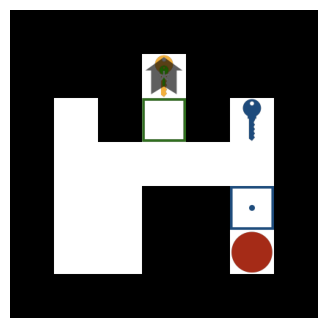

Step: 0
Return so far: 0
Instruction: Go to yellow key
Current observation: [1 3 4 2 0 1 3 3 2 1 2 5 2 2 0 5 5 1 1 0 2 3 3 0 4 5 2 1 1 3]
Agent is at 1, 3.
yellow key at 1, 3.
green key at 1, 3. Object in inventory.
blue key at 2, 5.
red ball at 5, 5.
green door at 2, 3 is unlocked.
blue door at 4, 5 is locked.
Choose action – 0:UP  1:DOWN  2:LEFT  3:RIGHT  4:PICK UP  5:DROP 6:USE


ValueError: invalid literal for int() with base 10: ''

In [ ]:
# ---- initial reset ----
obs = env.obs
step = 0
total_reward = 0
last_reward = None          # stores reward from previous step
terminated = truncated = False

while not (terminated or truncated):
    clear_output(wait=True)

    # -------- show current frame ----------
    frame = env.render_frame()
    show_frame(frame)

    # -------- show textual info -----------
    print(f"Step: {step}")
    print(f"Return so far: {total_reward}")
    if last_reward is not None:
        print(f"Reward from previous action: {last_reward}")
    print(f"Instruction: {obs['instr']}")
    print(f"Current observation: {obs['features']}")
    semantically_interpretable_state(obs=obs['features'], door_idx_0=20, agent_idx_0=28, features=hparams["features"])
    
    print("Choose action – 0:UP  1:DOWN  2:LEFT  3:RIGHT  4:PICK UP  5:DROP 6:USE")

    # -------- get action ------------------
    action = int(input("Your action index: ").strip())
    if action not in range(7):
        print("❌  Please enter an integer 0‑6.")
        break   

    # -------- environment step ------------
    next_obs, reward, terminated, truncated, _ = env.step(action)

    # update bookkeeping
    last_reward = reward
    total_reward += reward
    obs = next_obs
    step += 1

# final display
clear_output(wait=True)
frame = env.render_frame()
show_frame(frame)
print("Episode finished.")
print(f"Current observation: {obs}")
print(f"Total steps: {step}   Return: {total_reward}")
obs, _ = env.reset()